# 1. Introdução

# Modelos avançados
## Projeto: Credit Risk - Home Credit Default Risk

Após a construção do modelo baselne por meio da Regressão Logística, foi identificado que o principal desafio do projeto está reloacionado ao forte desbalancemaneto da variável target e à dificuldade de identificação da classe inadimplente.

Este notebook tem como objetivo explorar técnicas e modelos mais robustos, buscando melhorar a capacidade de discriminação entre cleintes adimplentes e inadimplentes.

# 2. Bibliotecas

In [1]:
# MANIPULAÇÃO DE DADOS
import pandas as pd
import numpy as np

# GRÁFICOS
import matplotlib.pyplot as plt

# METRICAS DE DECISÃO e SMOTE para teste de balanceamento das classes
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# MACHINE LEARNING
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 3. Carregamento dos Dados Processados


In [2]:
# Features
features_processed = pd.read_parquet('../data/processed/Features_processed.parquet')
# Target
target_processed = pd.read_parquet('../data/processed/Target_processed.parquet')
# APLICANDO A FUNÇÃO RAVEL() NOS VALORES DO TARGET PARA CONVERTER PARA UM COLUNA 1D
target_processed_corrigido = target_processed.values.ravel()

# 4. Divisão Treino/Teste

In [3]:
# DIVIDINDO OS DADOS ENTRE TREINO E TESTE
x_treino, x_teste, y_treino, y_teste = train_test_split(features_processed, target_processed_corrigido, shuffle = True, test_size = 0.3, random_state  = 0, stratify = target_processed_corrigido)

# 5. Tratamento do Desbalanceamento

O modelo baseline demonstrou elevado dificuldade em identificar clientes inadimplentes, evidenciado a necessidade de estratégias específicas para lidar com o desbalancemanto da variável target.

## 5.0 Balanced

In [10]:
# CRIAÇÃO DO MODELO
modelo_balanceado = LogisticRegression(max_iter = 1500, random_state = 0, class_weight = 'balanced')
# TREINANDO O MODELO
modelo_balanceado.fit(x_treino,  y_treino)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,0
,solver,'lbfgs'
,max_iter,1500
,multi_class,'deprecated'


### 5.1 Previsões do modelo

Nesta etapa é realizada as previsões do modelo e suas probabilidades

In [14]:
# REALIZANDO AS PREVISÕES
y_pred_bal = modelo_balanceado.predict(x_teste)
# OBTENDO A PROBABILIDADE DE CADA PREVISÃO
y_proba_bal = modelo_balanceado.predict_proba(x_teste)[:,1]

# REALIZANDO AS PREVISÕES
print('Previsões feitas pelo modelo:{}'.format(modelo_balanceado.predict(x_teste)))
# OBTENDO A PROBABILIDADE DE CADA PREVISÃO
print('Probabilidade das previsões:{}'.format(modelo_balanceado.predict_proba(x_teste)[:,1]))

Previsões feitas pelo modelo:[1 1 0 ... 0 1 0]
Probabilidade das previsões:[0.52667308 0.62865341 0.44219437 ... 0.33838795 0.61067679 0.33906219]


### 5.2 Classification_report

In [16]:
print(classification_report(y_teste, modelo_balanceado.predict(x_teste)))

              precision    recall  f1-score   support

           0       0.94      0.60      0.73     84806
           1       0.11      0.57      0.19      7448

    accuracy                           0.60     92254
   macro avg       0.53      0.59      0.46     92254
weighted avg       0.87      0.60      0.69     92254



### 5.3 Matriz de Confusão

In [18]:
print(confusion_matrix(y_teste, modelo_balanceado.predict(x_teste)))

[[50630 34176]
 [ 3178  4270]]


### 5.4 ROC AUC

In [33]:
print(roc_auc_score(y_teste, modelo_balanceado.predict(x_teste)))

0.5851589581103195


## Interpretação dos Resultados

A aplicação do parâmetro class_weight='balanced' promoveu uma mudança significativa no comportamento do modelo.

Diferentemente do modelo baseline, que classificava praticamente todas as observações como adimplentes, a nova abordagem foi capaz de identificar aproximadamente 57% dos clientes inadimplentes presentes no conjunto de teste.

Esse resultado evidencia que o forte desbalanceamento da variável target exercia impacto relevante sobre a capacidade de identificação da classe positiva.

Embora tenha ocorrido uma redução na acurácia global do modelo e na precisão da classe inadimplente, observa-se um aumento expressivo do recall, métrica considerada especialmente relevante em problemas de risco de crédito.

Os resultados demonstram que a ponderação das classes contribui para tornar o modelo mais sensível à identificação de clientes inadimplentes, ainda que ao custo de um aumento na quantidade de falsos positivos.

## 5.5 SMOTE

In [26]:
# CRIANDO O SMOTE
smote = SMOTE(random_state = 0)
x_treino_smote, y_treino_smote = smote.fit_resample(
    x_treino,
    y_treino
)
# CONVERTENDO EM SERIES PARA OBSERVAR A QUANTIDADE DE CADA CLASSE PÓS APLICAR SMOTE
pd.Series(y_treino_smote).value_counts()

0    197880
1    197880
Name: count, dtype: int64

In [28]:
# CRIANDO O MODELO DE REGRESSÃO LOGISTICA
modelo_smote = LogisticRegression(
    max_iter = 5000,
    random_state = 0
)
# TREINANDO O MODELO COM OS DADOS DE TREINO PÓS SMOTE
modelo_smote.fit(x_treino_smote, y_treino_smote)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


### 5.6 Previsões do Modelo

In [35]:
# REALIZANDO AS PREVISÕES DO MODELO COM SMOTE
y_pred_smote = modelo_smote.predict(x_teste)
# EXTRAINDO AS PROBABILIDADES DAS PREVISÕES
y_proba_smote = modelo_smote.predict_proba(x_teste)[:,1]

print(y_pred_smote)
print(y_proba_smote)

[0 1 1 ... 0 1 0]
[0.28092654 0.57170469 0.5558852  ... 0.08874181 0.71141685 0.11624669]


### 5.7 Classification Report

In [36]:
print(classification_report(y_teste, y_pred_smote))

              precision    recall  f1-score   support

           0       0.93      0.65      0.76     84806
           1       0.10      0.44      0.16      7448

    accuracy                           0.63     92254
   macro avg       0.51      0.54      0.46     92254
weighted avg       0.86      0.63      0.71     92254



### 5.8 Matriz de Confusão

In [37]:
print(confusion_matrix(y_teste, y_pred_smote))

[[54978 29828]
 [ 4195  3253]]


### 5.9 ROC-AUC SCORE

In [50]:
print(roc_auc_score(y_teste, y_proba_smote))

0.5703834204980075


## Comparação entre Estratégias de Balanceamento
Foram avaliadas duas estratégias para lidar com o forte desbalanceamento da variável target: a ponderação automática das classes (class_weight='balanced') e a técnica de oversampling sintético SMOTE.

A abordagem baseada em ponderação das classes apresentou os melhores resultados para o objetivo do projeto. O modelo foi capaz de identificar aproximadamente 57% dos clientes inadimplentes, representando uma evolução significativa em relação ao modelo baseline, que não identificava nenhum inadimplente.

Embora a aplicação do SMOTE tenha promovido um pequeno aumento na acurácia global do modelo, observou-se redução na capacidade de identificação da classe inadimplente, com recall de aproximadamente 44%.

Além disso, o desempenho medido pela métrica AUC-ROC também foi inferior ao obtido pela estratégia de ponderação das classes, indicando menor capacidade de separação entre clientes adimplentes e inadimplentes.

Os resultados sugerem que, para a Regressão Logística e para a estrutura atual dos dados, a estratégia class_weight='balanced' apresentou melhor equilíbrio entre discriminação e identificação da classe positiva.

# 6. Random Forest

Após avaliar diferentes estratégias para lidar com o desbalanceamento das classes em conjunto com a Regressão Logística, será explorado o algoritmo Random Forest.

Por se tratar de um modelo baseado em árvores de decisão, o Random Forest é capaz de capturar relações não lineares entre as variáveis, podendo identificar padrões mais complexos associados ao risco de inadimplência.

O objetivo desta etapa é verificar se um modelo mais robusto consegue melhorar a capacidade de identificação da classe inadimplente em relação aos modelos avaliados anteriormente.


In [41]:
# CRIAÇÃO DO MODELO
modelo_rf = RandomForestClassifier(n_estimators = 200, random_state = 0, class_weight = 'balanced', n_jobs = -1)
# TREINAMENTO DO MODELO
modelo_rf.fit(x_treino, y_treino)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 6.1 Previsões do Modelo

In [44]:
# REALIZANDO AS PREVISÕES
y_pred_rf = modelo_rf.predict(x_teste)
# OBTENDO A PROBABILIDADE DE CADA PREVISÃO
y_proba_rf = modelo_rf.predict_proba(x_teste)[:,1]

print(f'Previsões feitas pelo modelo: {y_pred_rf}')
print(f'Probabilidade das previsões: {y_proba_rf}')

Previsões feitas pelo modelo: [0 0 0 ... 0 0 0]
Probabilidade das previsões: [0.145 0.115 0.055 ... 0.025 0.205 0.055]


## 6.2 Classification Report

In [62]:
print(classification_report(y_teste, y_pred_rf))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     84806
           1       0.69      0.00      0.00      7448

    accuracy                           0.92     92254
   macro avg       0.80      0.50      0.48     92254
weighted avg       0.90      0.92      0.88     92254



## 6.3 Matriz de confusão

In [46]:
print(confusion_matrix(y_teste, y_pred_rf))

[[84801     5]
 [ 7437    11]]


## 6.4 ROC AUC SCORE

In [49]:
print(roc_auc_score(y_teste, y_proba_rf))

0.7313660716074722


## 6.5 ROC CURVE

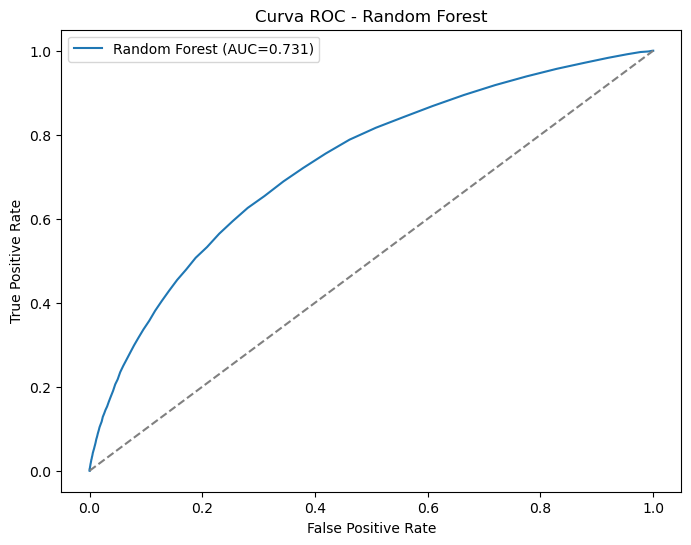

In [57]:
# CURVA ROC
fpr, tpr, thresholds = roc_curve(
    y_teste,
    y_proba_rf
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'Random Forest (AUC={roc_auc_score(y_teste, y_proba_rf):.3f})'
)

plt.plot(
    [0,1],
    [0,1],
    '--',
    color='gray'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Random Forest')
plt.legend()

plt.show()

## 6.6 Precision-Recall Curve

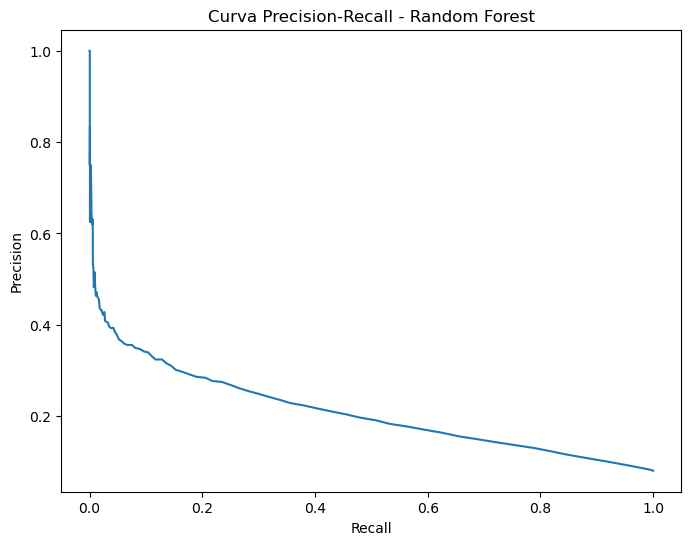

In [56]:
# CURVA DA PRECISÃO ~ RECALL
precision, recall, thresholds = precision_recall_curve(
    y_teste,
    y_proba_rf
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision
)

plt.xlabel('Recall')
plt.ylabel('Precision')

plt.title('Curva Precision-Recall - Random Forest')

plt.show()

## 6.7 AJUSTES DE THRESHOLD

In [61]:
for threshold in [0.10,0.15,0.20,0.25,0.30]:
    y_pred_custom = (y_proba_rf >= threshold).astype(int)
    print(f"Threshold:{threshold}")
    print(classification_report(y_teste, y_pred_custom))

Threshold:0.1
              precision    recall  f1-score   support

           0       0.95      0.75      0.84     84806
           1       0.17      0.59      0.26      7448

    accuracy                           0.73     92254
   macro avg       0.56      0.67      0.55     92254
weighted avg       0.89      0.73      0.79     92254

Threshold:0.15
              precision    recall  f1-score   support

           0       0.94      0.90      0.92     84806
           1       0.24      0.34      0.28      7448

    accuracy                           0.86     92254
   macro avg       0.59      0.62      0.60     92254
weighted avg       0.88      0.86      0.87     92254

Threshold:0.2
              precision    recall  f1-score   support

           0       0.93      0.96      0.95     84806
           1       0.29      0.18      0.22      7448

    accuracy                           0.90     92254
   macro avg       0.61      0.57      0.58     92254
weighted avg       0.88      0.

## Avaliação do Random Forest
Inicialmente, o Random Forest apresentou desempenho semelhante ao modelo baseline quando avaliado utilizando o threshold padrão de 0,50, classificando a maior parte das observações como adimplentes.

Entretanto, a análise das probabilidades previstas demonstrou elevada capacidade de separação entre as classes, refletida pelo AUC-ROC de aproximadamente 0,73, o melhor resultado obtido até o momento.

Ajustando o threshold de classificação para 0,10, observou-se aumento significativo da capacidade de identificação dos clientes inadimplentes, atingindo aproximadamente 59% de recall para a classe positiva.

Esse resultado evidencia que o modelo possuía forte capacidade discriminatória, mas que o threshold padrão ocultava parte do seu potencial preditivo.

# 7. XGBoost

Nesta etapa será avaliado o algoritmo XGBoost (Extreme Gradient Boosting), amplamente utilizado em competições de Machine Learning e problemas de risco de crédito devido à sua capacidade de capturar padrões complexos e melhorar a capacidade de discriminação entre clientes adimplentes e inadimplentes.

O objetivo é comparar seu desempenho com os modelos anteriormente avaliados.

In [ ]:
modelo_xgb = XGBoostClassifier()